# Titanic ML Notebook (Cleaned + Feature Engineering MAX)



In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Modeling
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# XGBoost (install with: pip install xgboost) if needed
from xgboost import XGBClassifier

pd.set_option("display.max_columns", None)

from IPython.display import display


In [2]:
# Load CSV files
train_raw = pd.read_csv("datasets/titanic/train.csv")
test_raw  = pd.read_csv("datasets/titanic/test.csv")

print("train_raw:", train_raw.shape)
print("test_raw :", test_raw.shape)
train_raw.head()


train_raw: (891, 12)
test_raw : (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Quick EDA

We will:
- Inspect missingness in train/test
- Visualize `Age` and `Fare` distributions to choose mean vs median imputation
- Check the class balance of the target (`Survived`) to choose an evaluation metric


In [3]:
# Missing value counts (train/test)
missing_train = train_raw.isna().sum().sort_values(ascending=False)
missing_test  = test_raw.isna().sum().sort_values(ascending=False)

print("Missing values (train):")
display(missing_train[missing_train > 0])

print("\nMissing values (test):")
display(missing_test[missing_test > 0])


Missing values (train):


Cabin       687
Age         177
Embarked      2
dtype: int64


Missing values (test):


Cabin    327
Age       86
Fare       1
dtype: int64

In [4]:
# Target distribution (imbalance check)
train_raw["Survived"].value_counts()


Survived
0    549
1    342
Name: count, dtype: int64

`Survived` is imbalanced (more 0s than 1s), so **accuracy** can be misleading.  
We will primarily evaluate models using **F1-score**, which balances precision and recall.

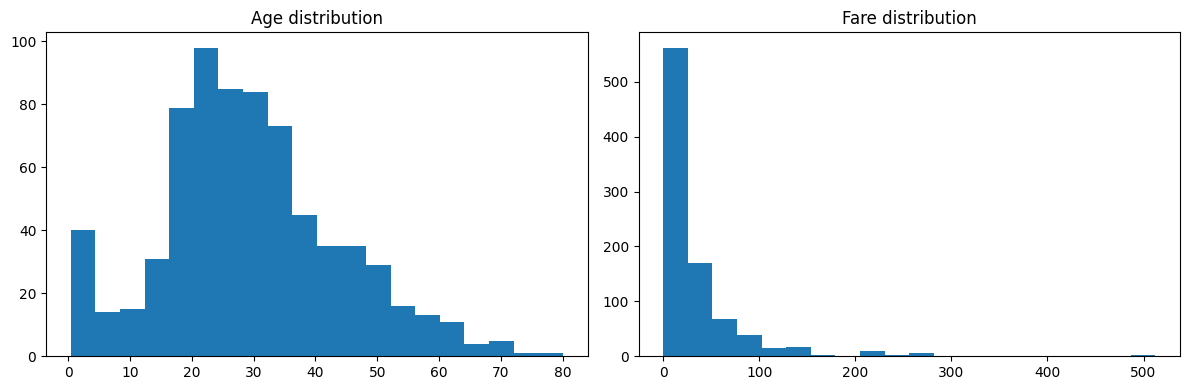

In [5]:
# Age and Fare histograms (train only — prevents leakage)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train_raw["Age"].dropna(), bins=20)
axes[0].set_title("Age distribution")

axes[1].hist(train_raw["Fare"].dropna(), bins=20)
axes[1].set_title("Fare distribution")

plt.tight_layout()
plt.show()


**Imputation choice (based on distributions):**
- `Age` is approximately symmetric → impute using the **mean**
- `Fare` is right-skewed with outliers → impute using the **median**

## Cleaning + Feature Engineering (Max)

This section builds a **feature-rich** dataset while staying careful about **data leakage**:
- We engineer features on the combined train+test frame for consistent encoding.
- Any *statistics* used for imputation (e.g., age/fare medians) are computed **from the training set only**.

Feature ideas included here:
- **Family / group**: `FamilySize`, `IsAlone`, buckets, ticket group size, fare per person
- **Name**: `Title`, `Surname` frequency, name length
- **Ticket**: prefix/letters, numeric flag, group size
- **Cabin**: has-cabin flag, deck letter, number of cabins
- **Demographics**: child/senior indicators, mother indicator

> Tip: Tree models (XGBoost) can handle many redundant features; linear models (LogReg) may prefer fewer or `drop_first=True`.


In [6]:
# Keep all rows (instead of dropping) and impute missing Embarked using the TRAIN mode.
train_df = train_raw.copy()
test_df  = test_raw.copy()

# Save PassengerId for submission BEFORE removing it from features
test_passenger_ids = test_df["PassengerId"].copy()

# --- Combine for consistent feature engineering / encoding ---
df_all = pd.concat([train_df, test_df], ignore_index=True)

# ---------------------------
# 0) Missingness indicators
# ---------------------------
df_all["AgeMissing"]      = df_all["Age"].isna().astype(int)
df_all["FareMissing"]     = df_all["Fare"].isna().astype(int)
df_all["CabinMissing"]    = df_all["Cabin"].isna().astype(int)
df_all["EmbarkedMissing"] = df_all["Embarked"].isna().astype(int)

# ---------------------------
# 1) Basic categorical cleanup
# ---------------------------
# Embarked: fill missing with TRAIN mode (prevents leakage)
embarked_mode = train_df["Embarked"].mode().iloc[0]
df_all["Embarked"] = df_all["Embarked"].fillna(embarked_mode)

# ---------------------------
# 2) Name-based features
# ---------------------------
def extract_title(name: str) -> str:
    """Extract a passenger title (e.g., Mr, Mrs, Miss) from the Name field."""
    if pd.isna(name):
        return "Unknown"
    return name.split(",")[1].split(".")[0].strip()

df_all["TitleRaw"] = df_all["Name"].apply(extract_title)

# Group rare titles into 'Rare' to reduce noise
rare_titles = ["Lady","Countess","Capt","Col","Don","Dr","Major","Rev","Sir","Jonkheer","Dona"]
df_all["Title"] = df_all["TitleRaw"].replace(rare_titles, "Rare")
df_all["Title"] = df_all["Title"].replace({"Mlle":"Miss","Ms":"Miss","Mme":"Mrs"})

# Surname + name length (frequency-encoded surname instead of one-hot)
df_all["Surname"] = df_all["Name"].str.split(",").str[0].str.strip()
df_all["NameLength"] = df_all["Name"].str.len()

surname_freq = df_all["Surname"].value_counts()
df_all["SurnameFreq"] = df_all["Surname"].map(surname_freq).fillna(1).astype(int)

# ---------------------------
# 3) Family / group features
# ---------------------------
df_all["FamilySize"] = df_all["SibSp"] + df_all["Parch"] + 1
df_all["IsAlone"] = (df_all["FamilySize"] == 1).astype(int)

# Bucket family size (captures non-linear effects)
df_all["FamilyBucket"] = pd.cut(
    df_all["FamilySize"],
    bins=[0, 1, 4, 11],
    labels=["Alone", "SmallFamily", "LargeFamily"]
)

# ---------------------------
# 4) Ticket features
# ---------------------------
# Ticket prefix/letters (cleaned)
def ticket_prefix(ticket: str) -> str:
    if pd.isna(ticket):
        return "none"
    parts = str(ticket).replace(".", "").replace("/", "").split()
    if len(parts) <= 1:
        return "none"
    return "".join(parts[:-1]).lower()

def ticket_number(ticket: str):
    if pd.isna(ticket):
        return np.nan
    parts = str(ticket).split()
    last = parts[-1]
    return int(last) if last.isdigit() else np.nan

df_all["TicketPrefix"] = df_all["Ticket"].apply(ticket_prefix)
df_all["TicketNumber"] = df_all["Ticket"].apply(ticket_number)
df_all["TicketIsNumeric"] = df_all["Ticket"].apply(lambda x: 1 if str(x).isnumeric() else 0)

# Ticket group size (people traveling together via same ticket)
df_all["TicketGroupSize"] = df_all.groupby("Ticket")["Ticket"].transform("count")

# ---------------------------
# 5) Cabin features
# ---------------------------
# Has cabin + deck letter + number of cabins listed
df_all["HasCabin"] = df_all["Cabin"].notna().astype(int)
df_all["Deck"] = df_all["Cabin"].str[0].fillna("Unknown")
df_all["NumCabins"] = df_all["Cabin"].apply(lambda x: 0 if pd.isna(x) else len(str(x).split()))

# ---------------------------
# 6) Imputation (train-only statistics)
# ---------------------------
# Fare: impute using TRAIN median by (Pclass, Embarked) as a sensible group statistic
fare_group_median = train_df.groupby(["Pclass","Embarked"])["Fare"].median()

def fill_fare(row):
    if not pd.isna(row["Fare"]):
        return row["Fare"]
    key = (row["Pclass"], row["Embarked"])
    if key in fare_group_median.index:
        return fare_group_median.loc[key]
    return train_df["Fare"].median()

df_all["Fare"] = df_all.apply(fill_fare, axis=1)

# Age: create title first (already done), then impute using TRAIN median by (Title, Sex, Pclass)
# (Median is robust; on Titanic it usually works well.)
train_titles = train_df["Name"].apply(extract_title).replace(rare_titles, "Rare").replace({"Mlle":"Miss","Ms":"Miss","Mme":"Mrs"})
age_group_median = pd.concat([train_titles.rename("Title"), train_df[["Sex","Pclass","Age"]]], axis=1)                    .groupby(["Title","Sex","Pclass"])["Age"].median()

overall_age = train_df["Age"].median()

def fill_age(row):
    if not pd.isna(row["Age"]):
        return row["Age"]
    key = (row["Title"], row["Sex"], row["Pclass"])
    if key in age_group_median.index:
        return age_group_median.loc[key]
    return overall_age

df_all["Age"] = df_all.apply(fill_age, axis=1)

# ---------------------------
# 7) Derived numeric transforms
# ---------------------------
df_all["LogFare"] = np.log1p(df_all["Fare"])
df_all["FarePerPerson"] = df_all["Fare"] / df_all["TicketGroupSize"]
df_all["LogFarePerPerson"] = np.log1p(df_all["FarePerPerson"])

# Age bins + helpful demographic flags
df_all["IsChild"]  = (df_all["Age"] < 16).astype(int)
df_all["IsSenior"] = (df_all["Age"] >= 60).astype(int)
df_all["IsMaster"] = (df_all["Title"] == "Master").astype(int)

# A classic Titanic heuristic feature: "Mother"
df_all["IsMother"] = (
    (df_all["Sex"] == "female") &
    (df_all["Parch"] > 0) &
    (df_all["Age"] > 18) &
    (df_all["Title"] != "Miss")
).astype(int)

# Remove target from feature frame to avoid leakage
if "Survived" in df_all.columns:
    df_all = df_all.drop(columns=["Survived"])


In [7]:
# ---------------------------
# 8) Drop raw columns (keep engineered ones)
# ---------------------------
# We remove raw text/high-cardinality columns after extracting signals.
# PassengerId is removed from features (we saved test_passenger_ids already).
drop_cols = ["PassengerId", "Name", "TitleRaw", "Surname", "Ticket", "Cabin", "SibSp", "Parch", "Fare", "TicketNumber"]
df_all = df_all.drop(columns=[c for c in drop_cols if c in df_all.columns])

# Treat Pclass as categorical (so it gets one-hot encoded)
df_all["Pclass"] = df_all["Pclass"].astype("category")


In [8]:
# ---------------------------
# 9) One-hot encode categoricals
# ---------------------------
# drop_first=True avoids perfect multicollinearity for linear models (LogReg).
df_all = pd.get_dummies(df_all, drop_first=True)

# Sanity check: any remaining missing values?
df_all.isna().sum().sum()


np.int64(0)

In [9]:
# Feature matrix shape (rows, columns) after encoding
df_all.shape


(1309, 74)

In [10]:
# Split back into train/test (preserving original row order)
n_train = len(train_df)

X_train = df_all.iloc[:n_train].copy()
X_test  = df_all.iloc[n_train:].copy()

y_train = train_df["Survived"].copy()

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape)


X_train: (891, 74) y_train: (891,)
X_test : (418, 74)


## Baseline CV (F1-score)

We use **StratifiedKFold** because `Survived` is imbalanced.

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression baseline (scaling helps for LR)
lr_baseline = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("lr", LogisticRegression(max_iter=5000))
])

lr_scores = cross_val_score(lr_baseline, X_train, y_train, cv=cv, scoring="f1")
print("LR F1 scores:", lr_scores)
print("LR mean F1 :", lr_scores.mean())


LR F1 scores: [0.80291971 0.75912409 0.73282443 0.76335878 0.75912409]
LR mean F1 : 0.7634702178637098


In [12]:
# XGBoost baseline (tree-based, scaling not required)
xgb_baseline = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb_scores = cross_val_score(xgb_baseline, X_train, y_train, cv=cv, scoring="f1")
print("XGB F1 scores:", xgb_scores)
print("XGB mean F1 :", xgb_scores.mean())


XGB F1 scores: [0.81751825 0.78787879 0.73846154 0.76470588 0.7518797 ]
XGB mean F1 : 0.7720888312233141


## Hyperparameter tuning

- **Logistic Regression**: GridSearchCV over `C`, solver, and class weights  
- **XGBoost**: RandomizedSearchCV over common depth/regularization/learning-rate parameters


In [13]:
# --- Logistic Regression tuning ---
pipe_lr = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("lr", LogisticRegression(max_iter=5000))
])

param_grid_lr = {
    "lr__solver": ["liblinear", "lbfgs"],
    "lr__penalty": ["l2"],
    "lr__C": np.logspace(-3, 3, 13),
    "lr__class_weight": [None, "balanced"]
}

grid_lr = GridSearchCV(
    pipe_lr,
    param_grid=param_grid_lr,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

print("Best LR params:", grid_lr.best_params_)
print("Best LR F1   :", grid_lr.best_score_)

best_lr = grid_lr.best_estimator_


/opt/anaconda3/envs/data_science/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/envs/data_science/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/envs/data_science/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be

Best LR params: {'lr__C': np.float64(0.01), 'lr__class_weight': 'balanced', 'lr__penalty': 'l2', 'lr__solver': 'liblinear'}
Best LR F1   : 0.7795996614608284


/opt/anaconda3/envs/data_science/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/envs/data_science/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/envs/data_science/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be

In [14]:
# --- XGBoost tuning ---
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

param_dist_xgb = {
    "n_estimators": [200, 400, 800, 1200],
    "max_depth": [2, 3, 4, 5],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.3, 0.5],
    "reg_alpha": [0, 0.001, 0.01, 0.1],
    "reg_lambda": [1, 1.5, 2, 3],
}

rand_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist_xgb,
    n_iter=60,     # increase for a more thorough search
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rand_xgb.fit(X_train, y_train)

print("Best XGB params:", rand_xgb.best_params_)
print("Best XGB F1   :", rand_xgb.best_score_)

best_xgb = rand_xgb.best_estimator_


Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best XGB params: {'subsample': 1.0, 'reg_lambda': 1.5, 'reg_alpha': 0.001, 'n_estimators': 400, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.6}
Best XGB F1   : 0.7882214605987804


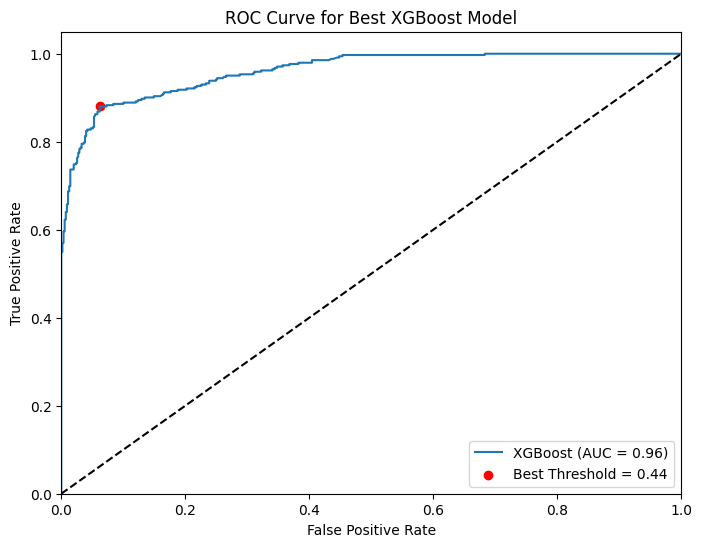

In [ ]:
# Plot ROC curve for the best XGBoost model
from sklearn.metrics import roc_curve, auc
y_proba_xgb = best_xgb.predict_proba(X_train)[:, 1]
fpr, tpr, thresholds = roc_curve(y_train, y_proba_xgb)
roc_auc = auc(fpr, tpr)

# Compute Youden's J statistic
J = tpr - fpr

# Find index of best threshold
ix = np.argmax(J)

best_threshold = thresholds[ix]

print("Best Threshold:", best_threshold)
print("Best TPR:", tpr[ix])
print("Best FPR:", fpr[ix])

plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.2f})')
plt.scatter(fpr[ix], tpr[ix], color='red', label=f'Best Threshold = {best_threshold:.2f}')

plt.plot([0, 1], [0, 1], 'k--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Best XGBoost Model')
plt.legend(loc="lower right")

plt.show()

## Fit best XGBoost on full training data + predict test set

In [20]:
# Fit best model on all training data
best_xgb.fit(X_train, y_train)

# Predict probabilities for Kaggle test set
test_proba = best_xgb.predict_proba(X_test)[:, 1]

# Apply ROC-selected threshold
test_preds = (test_proba >= best_threshold).astype(int)

# Create submission file
submission = pd.DataFrame({
    "PassengerId": test_passenger_ids,
    "Survived": test_preds
})

submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


In [21]:
# Save submission file
submission.to_csv("xgb_submission.csv", index=False)
print("Saved: xgb_submission.csv")


Saved: xgb_submission.csv
